In [1]:
import os

os.chdir('../')

In [2]:
import torch
import torch.nn.functional as F
import numpy as np
import scipy 

# Minimal change: keep your plotting logic identical, only loop over s3/s5/s7/s9.
import torch, numpy as np, matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# ---------- Palettes & colors (unchanged) ----------
PALETTES = [
    ["#FF2D55", "#00B8FF", "#00E676"],
    ["#1f77b4", "#ff7f0e", "#2ca02c"],  # Classic Blue–Orange–Green
    ["#d62728", "#1f77b4", "#7f7f7f"],  # Muted Red–Blue–Gray
    ["#4c78a8", "#f58518", "#54a24b"],  # Vega-Altair Set
    ["#2b83ba", "#abdda4", "#fdae61"],  # Nature Inspired
    ["#e69f00", "#56b4e9", "#009e73"],  # CUD (color-blind friendly)
    ["#377eb8", "#e41a1c", "#4d4d4d"],  # Cool–Warm–Neutral
    ["#8c510a", "#01665e", "#f5f5f5"],  # Earth Tone
    ["#e41a1c", "#377eb8", "#4daf4a"],  # Bold & Bright
    ["#984ea3", "#ff7f00", "#66a61e"],  # Dark Pastel
    ["#000000", "#7f7f7f", "#e6e6e6"],  # Grayscale Emphasis
]
PALETTE_INDEX = 0
PRED_COLOR = PALETTES[PALETTE_INDEX][0]
CORR_COLOR = PALETTES[PALETTE_INDEX][1]

# ---------- Style (ICLR-ready, unchanged) ----------
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 11,                    # 본문 크기
    "axes.titlesize": 12,               # 서브플롯 제목
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.linewidth": 0.8,
    "grid.alpha": 0.35,
    "mathtext.fontset": "cm",           # Computer Modern 수학 폰트
})

# (index, title, transform, refline) — unchanged
params = [
    (0, r'$\gamma$',  lambda a: np.tanh(a)*2.,          0.0),
    (1, r'$\tau_u$',  lambda a: scipy.special.softplus(1.0 + a),    1.0),
    (2, r'$\tau_v$',  lambda a: scipy.special.softplus(1.0 + a),    1.0),
    (3, r'$\kappa_u$',lambda a: np.tanh(a)*2,          0.0),
    (4, r'$\kappa_v$',lambda a: np.tanh(a)*2,          0.0),
]
lw = 1.5
ms = 4.5

def render(weight):
    tab = weight.data.cpu().float().numpy()  # [S,2,P]
    x   = np.arange(tab.shape[0])  # 0..S-1 (step index)

    fig, ax = plt.subplots(1, 5, figsize=(13.8, 2.8), sharex=True, dpi=100)  # unchanged

    for k, (idx, title, f, refline) in enumerate(params):
        pred = f(tab[:, 0, idx])
        corr_full = f(tab[:, 1, idx])

        # corr는 한 칸 당겨 정렬(corr[1:]) + 마지막 step은 아예 그리지 않음 — unchanged
        corr_shift = corr_full[1:]      # 길이: S-1
        x_corr     = x[:-1]             # 길이: S-1

        # 데이터 기반 여백 있는 y-범위 (마지막 corr 점 제외한 값으로 계산) — unchanged
        y = np.concatenate([pred, corr_shift])
        ypad = 0.08 * (np.nanmax(y) - np.nanmin(y) + 1e-9)
        ymin, ymax = np.nanmin(y) - ypad, np.nanmax(y) + ypad

        ax[k].plot(x,       pred, '-',  marker='o', ms=ms, lw=lw, label='Pred.', color=PRED_COLOR)
        ax[k].plot(x_corr,  corr_shift, '--', marker='s', ms=ms, lw=lw, label='Corr.', color=CORR_COLOR)

        ax[k].set_title(title, pad=6)
        ax[k].set_ylim(-2.3, 2.3)  # unchanged fixed range
        ax[k].set_xlabel('step')
        ax[k].xaxis.set_major_locator(MaxNLocator(integer=True))
        ax[k].grid(True, which='major')
        ax[k].tick_params(direction='out', length=4, width=0.8)
        for spine in ['top', 'right']:
            ax[k].spines[spine].set_visible(False)

    # 왼쪽 첫 축에만 y라벨 — unchanged
    ax[0].set_ylabel('value')

    # 범례: 첫 축에만, 프레임 제거 — unchanged
    ax[0].legend(loc='best', frameon=False, ncols=1)

    fig.tight_layout(w_pad=1.2)
    plt.show()

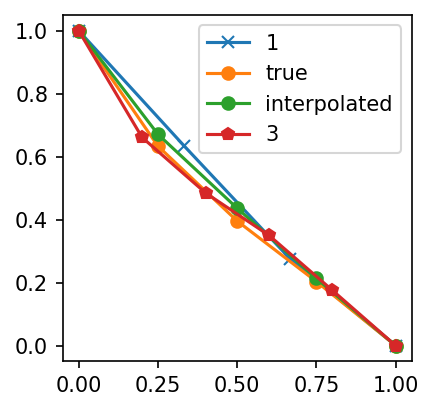

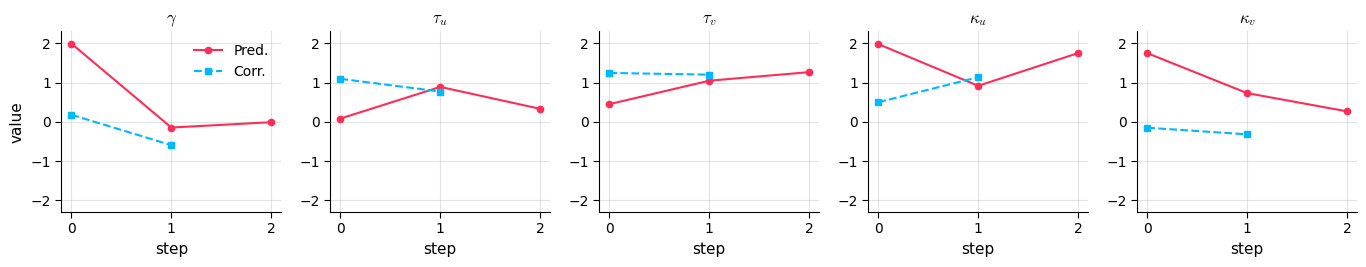

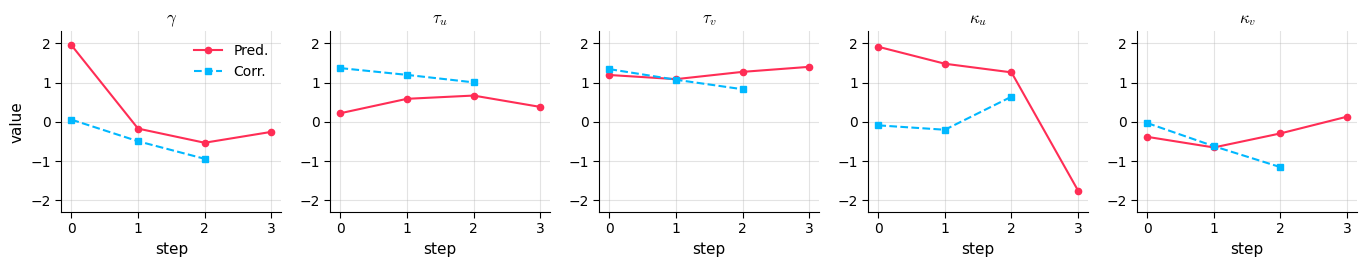

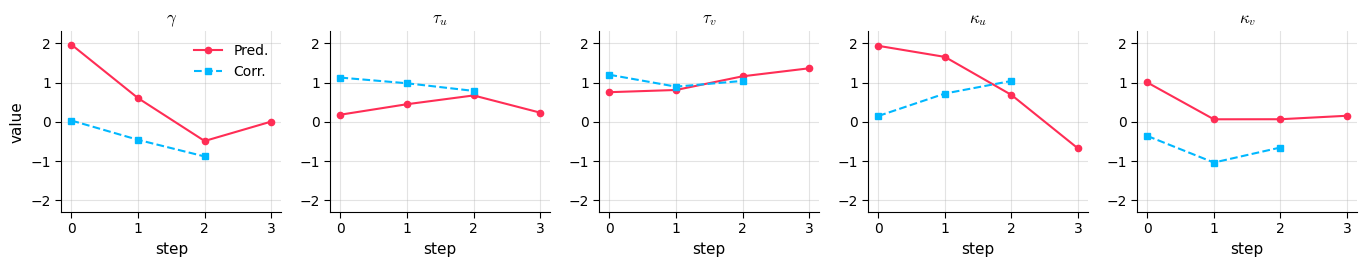

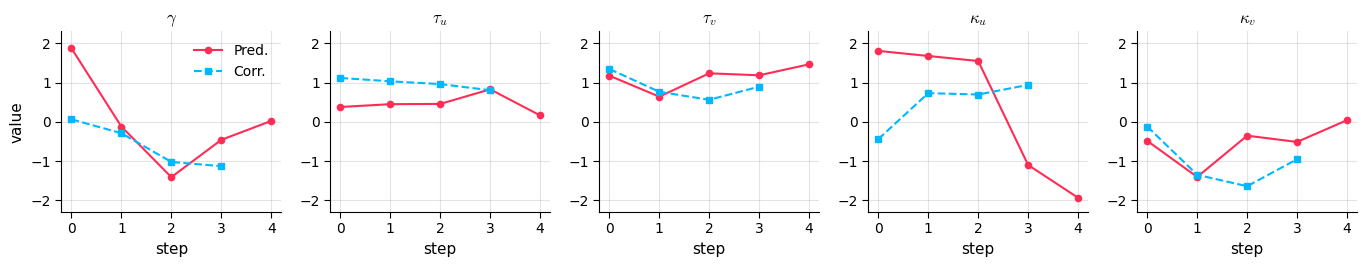

In [ ]:
from interpolation.interpolation1 import extract_log_deltas, get_timesteps, get_interplated_log_deltas, extract_weight, get_interpolated_weight

steps1 = 3
steps2 = 5
steps3 = 4

pt_file1 = f'logs/dit/mobile/s{steps1}/step_00020000.pt'
pt_file2 = f'logs/dit/mobile/s{steps2}/step_00020000.pt'
pt_file3 = f'logs/dit/mobile/s{steps3}/step_00020000.pt'

log_deltas1 = extract_log_deltas(pt_file1)
timesteps1 = get_timesteps(log_deltas1)
log_deltas2 = extract_log_deltas(pt_file2)
timesteps2 = get_timesteps(log_deltas2)
log_deltas3 = extract_log_deltas(pt_file3)
timesteps3 = get_timesteps(log_deltas3)
log_deltas3_inter = get_interplated_log_deltas(steps3, pt_file1, pt_file2)
timesteps3_inter = get_timesteps(log_deltas3_inter)

plt.figure(figsize=[3, 3])
plt.plot(np.linspace(0, 1, steps1 + 1), timesteps1.numpy(), marker='x', label='1')
plt.plot(np.linspace(0, 1, steps3 + 1), timesteps3.numpy(), marker='o', label='true')
plt.plot(np.linspace(0, 1, steps3 + 1), timesteps3_inter.numpy(), marker='o', label='interpolated')
plt.plot(np.linspace(0, 1, steps2 + 1), timesteps2.numpy(), marker='p', label='3')
plt.legend()
plt.show()

###

weight1 = extract_weight(pt_file1)
weight2 = extract_weight(pt_file2)
weight3 = extract_weight(pt_file3)
weight3_inter = get_interpolated_weight(steps3, weight1, weight2)

render(weight1)
render(weight3)
render(weight3_inter)
render(weight2)



In [16]:
for steps in [
[3, 5, 4],
[5, 7, 6],
[7, 9, 8],

[3, 6, 4],
[3, 6, 5],
[6, 9, 7],
[6, 9, 8],

[3, 9, 4],
[3, 9, 5],
[3, 9, 6],
[3, 9, 7],
[3, 9, 8],
]:
    pt_file1 = f'logs/dit/mobile/s{steps[0]}/step_00020000.pt'
    pt_file2 = f'logs/dit/mobile/s{steps[1]}/step_00020000.pt'
    
    log_deltas1 = extract_log_deltas(pt_file1)
    timesteps1 = get_timesteps(log_deltas1)
    log_deltas2 = extract_log_deltas(pt_file2)
    timesteps2 = get_timesteps(log_deltas2)
    log_deltas_inter = get_interplated_log_deltas(steps[2], pt_file1, pt_file2)
    
    weight1 = extract_weight(pt_file1)
    weight2 = extract_weight(pt_file2)
    weight_inter = get_interpolated_weight(steps[2], weight1, weight2)

    print(steps)
    print(log_deltas_inter.shape, weight_inter.shape)

    os.makedirs(f'logs/dit/mobile_interpolation1/s{steps[0]}{steps[1]}{steps[2]}', exist_ok=True)
    save_pt = f'logs/dit/mobile_interpolation1/s{steps[0]}{steps[1]}{steps[2]}/step_0020000.pt'
    print(save_pt)

    data = {'solver_state_dict': {'log_deltas': log_deltas_inter,
                                   'param_extractor.table': weight_inter}
           }
    torch.save(data, save_pt)

[3, 5, 4]
torch.Size([4]) torch.Size([4, 2, 5])
logs/dit/mobile_interpolation1/s354/step_0020000.pt
[5, 7, 6]
torch.Size([6]) torch.Size([6, 2, 5])
logs/dit/mobile_interpolation1/s576/step_0020000.pt
[7, 9, 8]
torch.Size([8]) torch.Size([8, 2, 5])
logs/dit/mobile_interpolation1/s798/step_0020000.pt
[3, 6, 4]
torch.Size([4]) torch.Size([4, 2, 5])
logs/dit/mobile_interpolation1/s364/step_0020000.pt
[3, 6, 5]
torch.Size([5]) torch.Size([5, 2, 5])
logs/dit/mobile_interpolation1/s365/step_0020000.pt
[6, 9, 7]
torch.Size([7]) torch.Size([7, 2, 5])
logs/dit/mobile_interpolation1/s697/step_0020000.pt
[6, 9, 8]
torch.Size([8]) torch.Size([8, 2, 5])
logs/dit/mobile_interpolation1/s698/step_0020000.pt
[3, 9, 4]
torch.Size([4]) torch.Size([4, 2, 5])
logs/dit/mobile_interpolation1/s394/step_0020000.pt
[3, 9, 5]
torch.Size([5]) torch.Size([5, 2, 5])
logs/dit/mobile_interpolation1/s395/step_0020000.pt
[3, 9, 6]
torch.Size([6]) torch.Size([6, 2, 5])
logs/dit/mobile_interpolation1/s396/step_0020000.pt


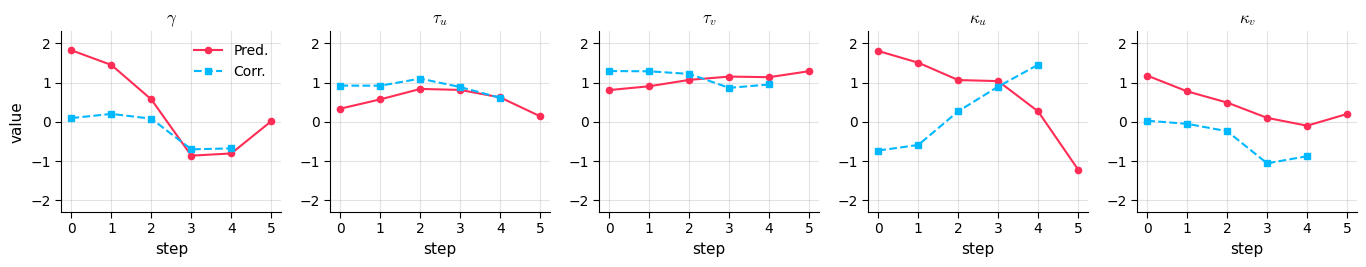

In [17]:
pt_file = f'logs/dit/mobile_interpolation1/s396/step_0020000.pt'
weight = extract_weight(pt_file)

render(weight)
